# Notebook 09 — Subject Exploration Dashboard

**Thesis Kinematic Pipeline v6.3 — Interactive Frontend**

This notebook is a **pure UI layer**. All analytical computation is delegated to `src/core_kinematics_engine.py`.
No metric math lives here — only widget definitions and callback wiring.

---

### Sections
- **Section 0** — Kernel Setup
- **Section 1** — Subject & Session Configuration
- **Section 2** — Pipeline Configuration
- **Section 3** — Run Engine
- **Section 4** — ATF Explorer
- **Section 5** — PCA & Dimensionality
- **Section 6** — Longitudinal Summary
- **Section 7** — Export

**Prerequisites:** Step-06 parquets present in `derivatives/step_06_kinematics/`.

---
## Section 0 — Kernel Setup

In [1]:
# ── Section 0: Kernel Setup ────────────────────────────────────────────────
import os
import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Project root discovery (identical to NB07 pattern) ────────────────────
if os.path.exists(os.path.join(os.getcwd(), "src")):
    PROJECT_ROOT = os.path.abspath(os.getcwd())
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

PROJECT_ROOT: c:\Users\drorh\OneDrive - Mobileye\Desktop\gaga
Python: 3.10.11


In [2]:
# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import yaml
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Engine — all analytical work lives here
from core_kinematics_engine import (
    # Stage 0
    discover_sessions,
    select_representative_sessions,
    SessionInfo,
    # Stage 1
    compute_session_atf,
    # Stage 3
    run_t1_anchored_pca,
    # Stage 4
    compute_all_thesis_metrics,
    ThesisMetricsBundle,
    ATFResult,
    # Stage 5
    assemble_results_dataframe,
    compute_delta_table,
    bootstrap_delta_ci,
    # Stage 6 — Visualization
    plot_atf_heatmap,
    plot_gini_trajectories,
    plot_entropy_landscape,
    plot_variance_structure,
    plot_longitudinal_summary,
    plot_cross_subject_trajectories,
    # Constants
    BRANCHES,
    ALL_19_JOINTS,
    AXIAL_JOINTS,
    PERIPHERAL_JOINTS,
    N_BINS_DEFAULT,
    VARIANCE_THRESHOLD_DEFAULT,
    SAMPEN_R_FRACTION_DEFAULT,
    RQA_EPSILON_PERCENTILE_DEFAULT,
    BOOTSTRAP_BLOCK_SEC_DEFAULT,
    MIN_CLEAN_FRACTION,
    FS,
)

print("Engine imported successfully.")

Engine imported successfully.


In [3]:
# ── Global paths & config ──────────────────────────────────────────────────
CONFIG_PATH = Path(PROJECT_ROOT) / "config" / "config_v1.yaml"
STEP06_DIR  = Path(PROJECT_ROOT) / "derivatives" / "step_06_kinematics"
RESULTS_DIR = Path(PROJECT_ROOT) / "results"
RESULTS_DIR.mkdir(exist_ok=True)

with open(CONFIG_PATH, "r") as _f:
    CFG = yaml.safe_load(_f)

print(f"Config loaded: {CONFIG_PATH.name}")
print(f"Step-06 dir  : {STEP06_DIR}")
print(f"Step-06 exists: {STEP06_DIR.exists()}")

Config loaded: config_v1.yaml
Step-06 dir  : c:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\derivatives\step_06_kinematics
Step-06 exists: True


In [4]:
# ── Global pipeline state ──────────────────────────────────────────────────
# All mutable state lives in this dict — avoids global name collisions.
_STATE = {
    "bundle"         : None,   # ThesisMetricsBundle (current subject)
    "all_bundles"    : {},     # subject_id -> ThesisMetricsBundle
    "results_df"     : None,   # tidy long-format DataFrame
    "delta_df"       : None,   # delta table
    "bootstrap_df"   : None,   # bootstrap CI table
    "pca_output"     : None,   # raw run_t1_anchored_pca() output (current subject)
    "all_pca_outputs": {},     # subject_id -> pca_output
    "atf_results"    : None,   # list[ATFResult] (current subject)
    "sessions"       : [],     # all discovered sessions
    "representative" : [],     # selected representative sessions (current subject)
    "atf_by_run"     : {},     # run_id -> ATFResult (across all subjects)
}

logging.basicConfig(level=logging.WARNING)
print("Global state initialized.")

Global state initialized.


---
## Section 1 — Subject & Session Configuration

In [5]:
# ── Section 1 widgets ─────────────────────────────────────────────────────
w_subject = widgets.Dropdown(
    options=[("Subject 651", "651"), ("Subject 671", "671"),
             ("Both (651 & 671)", "both")],
    value="651",
    description="Subject:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="320px"),
)

w_timepoints = widgets.SelectMultiple(
    options=["T1", "T2", "T3"],
    value=["T1", "T2", "T3"],
    description="Timepoints:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="320px", height="80px"),
)

w_session_strategy = widgets.RadioButtons(
    options=[
        ("Auto (lowest artifact)", "lowest_artifact"),
        ("R1 only", "R1"),
        ("R2 only", "R2"),
    ],
    value="lowest_artifact",
    description="Run strategy:",
    style={"description_width": "120px"},
)

w_preview_btn = widgets.Button(
    description="Preview Session Registry",
    button_style="info",
    icon="table",
    layout=widgets.Layout(width="220px"),
)

w_session_table_out = widgets.Output()


def _artifact_badge(pct: float) -> str:
    """Return coloured HTML badge for artifact percentage."""
    if pct >= 30:
        color, label = "#d9534f", "CRITICAL"
    elif pct >= 20:
        color, label = "#f0ad4e", "WARNING"
    else:
        color, label = "#5cb85c", "OK"
    return (f'<span style="background:{color};color:#fff;'
            f'padding:2px 6px;border-radius:3px;font-size:0.85em">{label}</span>')


def on_preview_clicked(b):
    with w_session_table_out:
        clear_output(wait=True)
        subject_ids = ["651", "671"] if w_subject.value == "both" else [w_subject.value]
        selected_tps = list(w_timepoints.value)

        all_sessions = []
        for sid in subject_ids:
            slist = discover_sessions(
                STEP06_DIR, subject_filter=sid, protocol_filter="P2"
            )
            all_sessions.extend(slist)

        _STATE["sessions"] = all_sessions

        # Filter to selected timepoints
        visible = [s for s in all_sessions if s.timepoint in selected_tps]

        if not visible:
            display(HTML("<b style='color:red'>No sessions found. "
                         "Check STEP06_DIR path.</b>"))
            return

        rows_html = ""
        for s in visible:
            badge = _artifact_badge(s.artifact_pct_any_joint)
            dead_marker = " <b>[DEAD]</b>" if s.is_dead else ""
            rows_html += (
                f"<tr>"
                f"<td>{s.subject_id}</td>"
                f"<td>{s.timepoint}</td>"
                f"<td>{s.run_num}</td>"
                f"<td>{s.duration_s:.1f}s</td>"
                f"<td>{s.artifact_pct_any_joint:.1f}% {badge}</td>"
                f"<td>{s.n_frames:,}{dead_marker}</td>"
                f"<td style='font-size:0.8em;color:#555'>{s.run_id[:50]}...</td>"
                f"</tr>"
            )

        table_html = (
            "<table style='border-collapse:collapse;font-family:monospace;font-size:0.9em'>"
            "<thead><tr style='background:#2c3e50;color:#fff'>"
            "<th>Subject</th><th>TP</th><th>Run</th>"
            "<th>Duration</th><th>Artifact %</th><th>Frames</th><th>Run ID</th>"
            "</tr></thead>"
            f"<tbody>{rows_html}</tbody></table>"
        )
        display(HTML(f"<p><b>{len(visible)} sessions found</b></p>{table_html}"))


w_preview_btn.on_click(on_preview_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 1 — Subject & Session Configuration</h3>"),
    widgets.HBox([w_subject, w_timepoints, w_session_strategy]),
    w_preview_btn,
    w_session_table_out,
]))

---
## Section 2 — Pipeline Configuration

In [12]:
# ── Section 2 widgets ─────────────────────────────────────────────────────

# ── Core flags ────────────────────────────────────────────────────────────
w_t1_anchor = widgets.Checkbox(
    value=True, description="T1-Anchored PCA",
    style={"description_width": "initial"},
)
w_activity_filter = widgets.Checkbox(
    value=True, description="Branch-local artifact filtering",
    style={"description_width": "initial"},
)
w_centroid_fallback = widgets.Checkbox(
    value=True, description="Auto-elevate Centroid Displacement (when entropy invalid)",
    style={"description_width": "initial"},
)

# ── Sensitivity sliders (§Update 5 — 5 parameters) ────────────────────────
w_n_bins = widgets.IntSlider(
    value=N_BINS_DEFAULT, min=15, max=50, step=1,
    description="Entropy bins (n_bins):",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
)
w_variance_threshold = widgets.FloatSlider(
    value=VARIANCE_THRESHOLD_DEFAULT, min=0.70, max=0.99, step=0.01,
    description="Variance threshold (N90):",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
    readout_format=".2f",
)
w_sampen_r = widgets.FloatSlider(
    value=SAMPEN_R_FRACTION_DEFAULT, min=0.05, max=0.50, step=0.01,
    description="SampEn r fraction:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
    readout_format=".2f",
)
w_rqa_eps = widgets.FloatSlider(
    value=RQA_EPSILON_PERCENTILE_DEFAULT, min=2.0, max=30.0, step=1.0,
    description="RQA ε percentile:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
    readout_format=".0f",
)
w_bootstrap_block = widgets.FloatSlider(
    value=BOOTSTRAP_BLOCK_SEC_DEFAULT, min=0.5, max=6.0, step=0.5,
    description="Bootstrap block (sec):",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
    readout_format=".1f",
)
w_min_clean = widgets.FloatSlider(
    value=MIN_CLEAN_FRACTION, min=0.50, max=0.95, step=0.01,
    description="Min clean fraction:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px"),
    continuous_update=False,
    readout_format=".2f",
)

# ── Time-window crop (§Update 3) ───────────────────────────────────────────
def _crop_row(label):
    lbl = widgets.Label(value=label, layout=widgets.Layout(width="40px"))
    start = widgets.FloatText(
        value=0.0, description="start (s):",
        style={"description_width": "70px"},
        layout=widgets.Layout(width="180px"),
    )
    end = widgets.FloatText(
        value=0.0, description="end (s):",
        style={"description_width": "60px"},
        layout=widgets.Layout(width="170px"),
    )
    use = widgets.Checkbox(
        value=False, description="Crop",
        style={"description_width": "initial"},
        layout=widgets.Layout(width="80px"),
    )
    return widgets.HBox([lbl, use, start, end]), start, end, use

_t1_crop_row, w_t1_crop_start, w_t1_crop_end, w_t1_crop_use = _crop_row("T1")
_t2_crop_row, w_t2_crop_start, w_t2_crop_end, w_t2_crop_use = _crop_row("T2")
_t3_crop_row, w_t3_crop_start, w_t3_crop_end, w_t3_crop_use = _crop_row("T3")

# ── Advanced accordion (noise-floor overrides) ─────────────────────────────
w_advanced_content = widgets.Textarea(
    value="# Joint noise-floor overrides (JSON)\n# e.g.: {\"Hips\": 0.05}\n{}",
    layout=widgets.Layout(width="460px", height="80px"),
)
w_advanced_acc = widgets.Accordion(children=[w_advanced_content])
w_advanced_acc.set_title(0, "Advanced: Per-joint noise-floor overrides (JSON)")
w_advanced_acc.selected_index = None  # collapsed by default

# ── Layout ─────────────────────────────────────────────────────────────────
display(widgets.VBox([
    widgets.HTML("<h3>Section 2 — Pipeline Configuration</h3>"),
    widgets.HTML("<b>Core options</b>"),
    widgets.HBox([w_t1_anchor, w_activity_filter, w_centroid_fallback]),
    widgets.HTML("<b>Sensitivity parameters</b>"),
    w_n_bins,
    w_variance_threshold,
    w_sampen_r,
    w_rqa_eps,
    w_bootstrap_block,
    w_min_clean,
    widgets.HTML("<b>Time-window crop</b> (leave 'Crop' unchecked to use full session)"),
    _t1_crop_row,
    _t2_crop_row,
    _t3_crop_row,
    w_advanced_acc,
]))

---
## Section 3 — Run Engine

In [13]:
# ── Section 3 widgets ─────────────────────────────────────────────────────
w_run_btn = widgets.Button(
    description="▶ Run Full Pipeline",
    button_style="success",
    icon="play",
    layout=widgets.Layout(width="220px", height="40px"),
)
w_run_out = widgets.Output()


def _resolve_time_windows() -> dict[str, list]:
    """Read crop widgets → time_windows dict for run_t1_anchored_pca."""
    windows = {}
    for tp, use_w, start_w, end_w in [
        ("T1", w_t1_crop_use, w_t1_crop_start, w_t1_crop_end),
        ("T2", w_t2_crop_use, w_t2_crop_start, w_t2_crop_end),
        ("T3", w_t3_crop_use, w_t3_crop_start, w_t3_crop_end),
    ]:
        if use_w.value:
            windows[tp] = [float(start_w.value), float(end_w.value)]
    return windows or None


def _display_run_summary(bundle: ThesisMetricsBundle) -> None:
    """Print a concise per-session summary table (pure display, no math)."""
    lines = [f"<b>Subject {bundle.subject_id} — {len(bundle.timepoints)} sessions</b>"]
    rows = ""
    for i, tp in enumerate(bundle.timepoints):
        concern = bundle.atf_artifact_concern[i]
        badge_color = {"OK": "#5cb85c", "WARNING": "#f0ad4e",
                       "CRITICAL": "#d9534f"}.get(concern, "#aaa")
        badge = (f'<span style="background:{badge_color};color:#fff;'
                 f'padding:1px 5px;border-radius:3px;font-size:0.82em">{concern}</span>')
        atf_wb = bundle.atf_whole_body[i]
        rows += (
            f"<tr><td>{bundle.run_ids[i][:45]}…</td>"
            f"<td>{tp}</td>"
            f"<td>{atf_wb:.3f}</td>"
            f"<td>{bundle.atf_clean_fraction[i]:.1%}</td>"
            f"<td>{badge}</td>"
            f"</tr>"
        )
    table = (
        "<table style='border-collapse:collapse;font-size:0.88em'>"
        "<thead><tr style='background:#2c3e50;color:#fff'>"
        "<th>Run ID</th><th>TP</th><th>ATF (whole-body)</th>"
        "<th>Clean frames</th><th>Artifact</th>"
        "</tr></thead>"
        f"<tbody>{rows}</tbody></table>"
    )
    display(HTML("\n".join(lines) + "\n" + table))
    display(HTML("<p style='color:green'>✔ Pipeline complete. "
                 "Proceed to Sections 4–6 for results.</p>"))


def on_run_clicked(b):
    with w_run_out:
        clear_output(wait=True)

        subject_ids = (["651", "671"]
                       if w_subject.value == "both"
                       else [w_subject.value])
        selected_tps = list(w_timepoints.value)
        strategy     = w_session_strategy.value
        time_windows = _resolve_time_windows()

        # ── Sensitivity params (§Update 5) ────────────────────────────────
        n_bins            = int(w_n_bins.value)
        var_thresh        = float(w_variance_threshold.value)
        sampen_r          = float(w_sampen_r.value)
        rqa_eps_pct       = float(w_rqa_eps.value)
        bootstrap_blk_sec = float(w_bootstrap_block.value)
        min_clean_frac    = float(w_min_clean.value)

        all_results_dfs = []
        all_delta_dfs   = []

        for subject_id in subject_ids:
            display(HTML(f"<p>⏳ Processing subject <b>{subject_id}</b>…</p>"))

            # ── Stage 0: Discover & select sessions ───────────────────────
            all_sessions = discover_sessions(
                STEP06_DIR,
                subject_filter=subject_id,
                protocol_filter="P2",
            )
            _STATE["sessions"] = all_sessions

            sessions_for_tp = [
                s for s in all_sessions if s.timepoint in selected_tps
            ]
            representative = select_representative_sessions(
                sessions_for_tp, strategy=strategy
            )
            _STATE["representative"] = representative

            if not representative:
                display(HTML(
                    f"<p style='color:red'>No valid sessions found for "
                    f"subject {subject_id}. Check Step-06 dir.</p>"
                ))
                continue

            tp_found = sorted({s.timepoint for s in representative})
            display(HTML(
                f"<p>Found {len(representative)} representative sessions: "
                f"{tp_found}</p>"
            ))

            # ── Stage 1: ATF per session ───────────────────────────────────
            display(HTML("<p>  Computing ATF…</p>"))
            atf_results_list: list[ATFResult] = []
            for si in representative:
                df_raw = pd.read_parquet(si.parquet_path)
                atf_r  = compute_session_atf(df_raw, CFG)
                atf_r.run_id = si.run_id
                atf_results_list.append(atf_r)
                _STATE["atf_by_run"][si.run_id] = atf_r

            _STATE["atf_results"] = atf_results_list

            # Check min clean fraction gate
            excluded = [
                (si.run_id, atf_r.clean_fraction)
                for si, atf_r in zip(representative, atf_results_list)
                if atf_r.clean_fraction < min_clean_frac
            ]
            if excluded:
                display(HTML(
                    f"<p style='color:orange'>⚠ Sessions below min clean "
                    f"fraction ({min_clean_frac:.0%}): "
                    + ", ".join(f"{rid[:40]} ({cf:.1%})" for rid, cf in excluded)
                    + "</p>"
                ))

            # ── Stage 3: T1-Anchored PCA ──────────────────────────────────
            display(HTML("<p>  Running T1-anchored PCA…</p>"))
            pca_output = run_t1_anchored_pca(
                representative,
                time_windows=time_windows,
            )
            _STATE["pca_output"] = pca_output
            _STATE["all_pca_outputs"][subject_id] = pca_output

            # ── Stage 4: All thesis metrics ───────────────────────────────
            display(HTML("<p>  Computing thesis metrics…</p>"))
            bundle = compute_all_thesis_metrics(
                pca_output,
                atf_results_list,
                subject_id=subject_id,
                n_bins=n_bins,
                variance_threshold=var_thresh,
                sampen_r_fraction=sampen_r,
                rqa_epsilon_percentile=rqa_eps_pct,
                bootstrap_block_sec=bootstrap_blk_sec,
            )
            _STATE["bundle"] = bundle
            _STATE["all_bundles"][subject_id] = bundle

            # ── Stage 5: Results assembly ─────────────────────────────────
            results_df = assemble_results_dataframe(bundle)
            all_results_dfs.append(results_df)

            _display_run_summary(bundle)

        # ── Combine across subjects ───────────────────────────────────────
        if all_results_dfs:
            combined_results = pd.concat(all_results_dfs, ignore_index=True)
            _STATE["results_df"] = combined_results
            _STATE["delta_df"]   = compute_delta_table(combined_results)
            display(HTML(
                f"<p style='color:#2c3e50'><b>Results ready:</b> "
                f"{len(combined_results):,} rows across "
                f"{combined_results['subject_id'].nunique()} subject(s).</p>"
            ))


w_run_btn.on_click(on_run_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 3 — Run Engine</h3>"),
    w_run_btn,
    w_run_out,
]))

---
## Section 4 — ATF Explorer

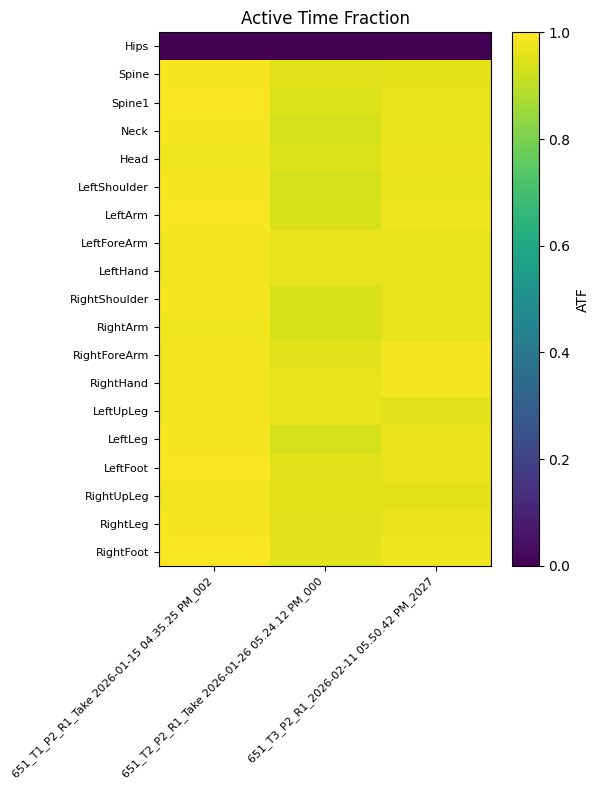

In [14]:
# ── Section 4 widgets ─────────────────────────────────────────────────────
import plotly.graph_objects as go  # already imported in engine; safe here for display
import plotly.io as pio
pio.renderers.default = "notebook"

w_atf_out = widgets.Output()
w_atf_refresh_btn = widgets.Button(
    description="Refresh ATF Plots",
    button_style="primary",
    icon="refresh",
    layout=widgets.Layout(width="200px"),
)


def _plot_atf_per_joint_trajectories(bundle: ThesisMetricsBundle) -> None:
    """Tab 1: Per-joint ATF trajectories (line chart per joint group)."""
    tps = bundle.timepoints
    from plotly.subplots import make_subplots

    groups = {
        "Axial": list(AXIAL_JOINTS),
        "Peripheral": list(PERIPHERAL_JOINTS),
        "Transitional": [
            j for j in ALL_19_JOINTS
            if j not in AXIAL_JOINTS and j not in PERIPHERAL_JOINTS
        ],
    }
    fig = make_subplots(rows=1, cols=3, subplot_titles=list(groups.keys()),
                        shared_yaxes=True)
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
              "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]

    for col_idx, (group_name, joint_list) in enumerate(groups.items(), start=1):
        for j_idx, joint in enumerate(joint_list):
            y_vals = [
                bundle.atf_per_joint[i].get(joint, float("nan"))
                for i in range(len(tps))
            ]
            fig.add_trace(
                go.Scatter(
                    x=tps, y=y_vals,
                    mode="lines+markers",
                    name=joint,
                    line=dict(color=colors[j_idx % len(colors)]),
                    showlegend=(col_idx == 1),
                ),
                row=1, col=col_idx,
            )
    fig.update_yaxes(range=[0, 1], title_text="ATF", row=1, col=1)
    fig.update_layout(
        title=f"Per-Joint ATF Trajectories — Subject {bundle.subject_id}",
        height=450,
    )
    fig.show()


def _plot_atf_axial_vs_peripheral(bundle: ThesisMetricsBundle) -> None:
    """Tab 2: Axial vs Peripheral grouped bar chart."""
    tps = bundle.timepoints

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=tps, y=bundle.atf_axial,
        name="Axial (5 joints)", marker_color="#3498db",
    ))
    fig.add_trace(go.Bar(
        x=tps, y=bundle.atf_distal,
        name="Peripheral/Distal (6 joints)", marker_color="#e74c3c",
    ))
    fig.add_trace(go.Scatter(
        x=tps, y=bundle.atf_whole_body,
        mode="lines+markers",
        name="Whole-body (median)",
        line=dict(color="#2ecc71", width=2, dash="dot"),
    ))
    fig.update_yaxes(range=[0, 1])
    fig.update_layout(
        title=f"Axial vs Peripheral ATF — Subject {bundle.subject_id}",
        yaxis_title="ATF",
        barmode="group",
        height=400,
    )
    fig.show()


def on_atf_refresh_clicked(b):
    with w_atf_out:
        clear_output(wait=True)
        bundle = _STATE.get("bundle")
        if bundle is None:
            display(HTML("<p style='color:red'>Run the pipeline first (Section 3).</p>"))
            return

        # Artifact concern warnings
        for i, concern in enumerate(bundle.atf_artifact_concern):
            if concern != "OK":
                color = "#f0ad4e" if concern == "WARNING" else "#d9534f"
                display(HTML(
                    f"<p style='color:{color}'>⚠ {bundle.run_ids[i][:50]}… — "
                    f"Artifact concern: <b>{concern}</b> "
                    f"(clean: {bundle.atf_clean_fraction[i]:.1%})</p>"
                ))

        # ── Tabs ──────────────────────────────────────────────────────────
        tab_out_0 = widgets.Output()
        tab_out_1 = widgets.Output()
        tab_out_2 = widgets.Output()

        tab4 = widgets.Tab(children=[tab_out_0, tab_out_1, tab_out_2])
        tab4.set_title(0, "Heatmap")
        tab4.set_title(1, "Per-Joint Trajectories")
        tab4.set_title(2, "Axial vs Peripheral")
        display(tab4)

        with tab_out_0:
            atf_by_run = _STATE["atf_by_run"]
            subject_ids = list({bundle.subject_id})
            fig_pl, fig_mpl = plot_atf_heatmap(atf_by_run, subject_ids)
            if fig_pl:
                fig_pl.show()
            else:
                display(HTML("<p>Plotly not available.</p>"))

        with tab_out_1:
            _plot_atf_per_joint_trajectories(bundle)

        with tab_out_2:
            _plot_atf_axial_vs_peripheral(bundle)


w_atf_refresh_btn.on_click(on_atf_refresh_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 4 — ATF Explorer</h3>"),
    w_atf_refresh_btn,
    w_atf_out,
]))

---
## Section 5 — PCA & Dimensionality

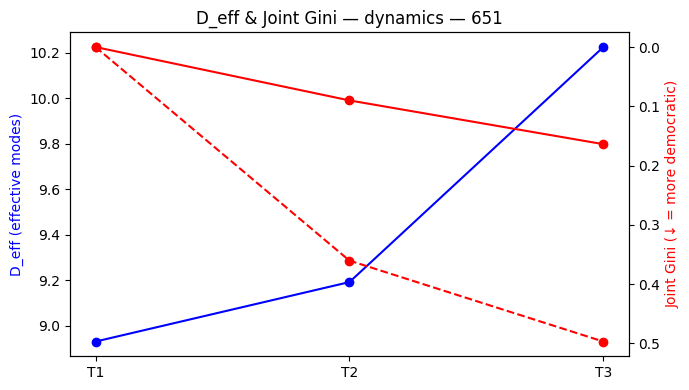

In [15]:
# ── Section 5 widgets ─────────────────────────────────────────────────────
w_branch = widgets.RadioButtons(
    options=[
        ("Dynamics (velocity)", "dynamics"),
        ("Pose (rotation vector)", "pose"),
        ("Reach (end-effector)", "reach"),
    ],
    value="dynamics",
    description="Branch:",
    style={"description_width": "80px"},
)

w_pca_refresh_btn = widgets.Button(
    description="Refresh PCA Plots",
    button_style="primary",
    icon="refresh",
    layout=widgets.Layout(width="200px"),
)
w_pca_out = widgets.Output()


def on_pca_refresh_clicked(b):
    with w_pca_out:
        clear_output(wait=True)
        bundle     = _STATE.get("bundle")
        pca_output = _STATE.get("pca_output")
        if bundle is None or pca_output is None:
            display(HTML("<p style='color:red'>Run the pipeline first (Section 3).</p>"))
            return

        branch = w_branch.value

        # ── Entropy reliability alert ──────────────────────────────────────
        ev_valid = bundle.entropy_valid.get(branch, [])
        pc12_cov = bundle.pc1pc2_var_coverage.get(branch, [])
        for i, (valid, cov) in enumerate(zip(ev_valid, pc12_cov)):
            if not valid:
                tp = bundle.timepoints[i] if i < len(bundle.timepoints) else f"idx{i}"
                display(HTML(
                    f"<div style='background:#fffacd;border:1px solid #e0c000;"
                    f"padding:8px;border-radius:4px;margin:4px 0'>"
                    f"⚠ <b>Entropy reliability warning ({tp}):</b> "
                    f"PC1+PC2 variance = {cov:.1%}. "
                    f"Centroid Displacement has been elevated to primary status."
                    f"</div>"
                ))

        # ── Four-tab layout ───────────────────────────────────────────────
        tab_out_0 = widgets.Output()
        tab_out_1 = widgets.Output()
        tab_out_2 = widgets.Output()
        tab_out_3 = widgets.Output()

        tab5 = widgets.Tab(
            children=[tab_out_0, tab_out_1, tab_out_2, tab_out_3]
        )
        tab5.set_title(0, "Variance Structure")
        tab5.set_title(1, "Effective Dimensionality")
        tab5.set_title(2, "Joint Gini")
        tab5.set_title(3, "State-Space Exploration")
        display(tab5)

        # Tab 0 — Variance Structure (cumulative variance + N90 + D_eff)
        with tab_out_0:
            pca_results  = pca_output["pca_results"]
            n90_results  = {b: {"n90_per_session": bundle.n90.get(b, []),
                                "d_eff_per_session": bundle.d_eff.get(b, [])}
                            for b in BRANCHES}
            d_eff_results = n90_results  # same structure used here
            fig_pl, fig_mpl = plot_variance_structure(
                pca_results, n90_results, d_eff_results, branch=branch
            )
            if fig_pl:
                fig_pl.show()
            else:
                display(HTML("<p>plot_variance_structure unavailable.</p>"))

        # Tab 1 — D_eff trajectory
        with tab_out_1:
            tps   = bundle.timepoints
            deff  = bundle.d_eff.get(branch, [])
            deffn = bundle.d_eff_norm.get(branch, [])
            n90v  = bundle.n90.get(branch, [])

            fig = go.Figure()
            fig.add_trace(go.Scatter(
                x=tps, y=deff, mode="lines+markers",
                name="D_eff (effective modes)",
                line=dict(color="#2980b9", width=2),
                marker=dict(size=10),
            ))
            fig.add_trace(go.Scatter(
                x=tps, y=n90v, mode="lines+markers",
                name=f"N{int(bundle.variance_threshold*100)} (components)",
                line=dict(color="#27ae60", width=2, dash="dot"),
                yaxis="y2",
            ))
            fig.update_layout(
                title=f"Effective Dimensionality — {branch} — Subject {bundle.subject_id}",
                yaxis=dict(title="D_eff"),
                yaxis2=dict(title="N90 (components)", overlaying="y",
                            side="right", showgrid=False),
                height=420,
            )
            fig.show()

        # Tab 2 — Joint Gini
        with tab_out_2:
            fig_pl, fig_mpl = plot_gini_trajectories(bundle, branch=branch)
            if fig_pl:
                fig_pl.show()
            else:
                display(HTML("<p>plot_gini_trajectories unavailable.</p>"))

        # Tab 3 — State-Space Exploration
        with tab_out_3:
            fig_ent = plot_entropy_landscape(bundle, pca_output, branch=branch)
            if fig_ent:
                fig_ent.show()
            else:
                display(HTML("<p>plot_entropy_landscape unavailable.</p>"))
            # Centroid displacement supplement
            tps_b   = bundle.timepoints
            cent_r  = bundle.centroid_displacement_raw.get(branch, [])
            cent_n  = bundle.centroid_displacement_norm.get(branch, [])
            if cent_r:
                fig_c = go.Figure()
                fig_c.add_trace(go.Bar(
                    x=tps_b, y=cent_r, name="Raw (PC units)",
                    marker_color="#9b59b6",
                ))
                fig_c.add_trace(go.Bar(
                    x=tps_b, y=cent_n,
                    name="Normalized (T1 PC1 std)",
                    marker_color="#8e44ad", opacity=0.6,
                ))
                fig_c.update_layout(
                    title=f"Centroid Displacement from T1 — {branch}",
                    barmode="group", height=350,
                )
                fig_c.show()
                display(HTML(
                    "<p style='font-size:0.85em;color:#555'>"
                    "⚠ Cross-branch magnitude comparisons are invalid (L16). "
                    "Within-branch T1→T3 comparison only.</p>"
                ))


w_pca_refresh_btn.on_click(on_pca_refresh_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 5 — PCA & Dimensionality</h3>"),
    w_branch,
    w_pca_refresh_btn,
    w_pca_out,
]))

---
## Section 6 — Longitudinal Summary

In [16]:
# ── Section 6 widgets ─────────────────────────────────────────────────────
w_summary_refresh_btn = widgets.Button(
    description="Refresh Summary",
    button_style="primary",
    icon="refresh",
    layout=widgets.Layout(width="200px"),
)
w_run_bootstrap_btn = widgets.Button(
    description="Run Bootstrap CI (slow)",
    button_style="warning",
    icon="cog",
    layout=widgets.Layout(width="220px"),
)
w_summary_out = widgets.Output()


def _hypothesis_assessment(delta_df: pd.DataFrame) -> str:
    """Auto-populate H1/H2/H3 text from consistency gate (no math here)."""

    def _assess(metric_filt, branch_filt=None) -> str:
        sub = delta_df[delta_df["metric"] == metric_filt].copy()
        if branch_filt:
            sub = sub[sub["branch"] == branch_filt]
        if sub.empty:
            return "<i>insufficient data</i>"
        labels = sub["cross_subject_consistency"].unique().tolist()
        if not labels:
            return "<i>insufficient data</i>"
        color = "#27ae60" if any("Convergent" in l or "Same" in l for l in labels) else "#c0392b"
        return f"<span style='color:{color}'>{'; '.join(labels)}</span>"

    h1_deff  = _assess("d_eff", "dynamics")
    h1_gini  = _assess("gini_joint_anchored", "dynamics")
    h2_entr  = _assess("state_space_entropy_bits_equalized", "dynamics")
    h3_atf   = _assess("atf_whole_body_median")

    return f"""
    <div style='background:#f8f9fa;border:1px solid #dee2e6;
                padding:12px;border-radius:6px;font-family:sans-serif'>
    <h4>Hypothesis Assessment (auto-generated from consistency gate)</h4>
    <b>H1 — Increased motor flexibility (D_eff ↑, Gini ↓):</b><br>
    &nbsp;&nbsp; D_eff (dynamics): {h1_deff}<br>
    &nbsp;&nbsp; Joint Gini (dynamics, anchored): {h1_gini}<br><br>
    <b>H2 — Expanded state-space (Entropy ↑):</b><br>
    &nbsp;&nbsp; State-space entropy (dynamics): {h2_entr}<br><br>
    <b>H3 — Increased movement activity (ATF ↑):</b><br>
    &nbsp;&nbsp; Whole-body ATF: {h3_atf}<br>
    </div>
    """


def on_summary_refresh_clicked(b):
    with w_summary_out:
        clear_output(wait=True)
        delta_df   = _STATE.get("delta_df")
        results_df = _STATE.get("results_df")

        if delta_df is None or results_df is None:
            display(HTML("<p style='color:red'>Run the pipeline first (Section 3).</p>"))
            return

        # ── Longitudinal summary plot ──────────────────────────────────────
        bootstrap_df = _STATE.get("bootstrap_df")
        fig_pl, fig_mpl = plot_longitudinal_summary(delta_df)
        if fig_pl:
            fig_pl.show()

        # ── Cross-subject trajectories (both subjects) ─────────────────────
        if results_df["subject_id"].nunique() > 1:
            fig_cross, _ = plot_cross_subject_trajectories(delta_df)
            if fig_cross:
                display(HTML("<h4>Cross-Subject Trajectories</h4>"))
                fig_cross.show()

        # ── Bootstrap CI table (if available) ─────────────────────────────
        if bootstrap_df is not None and not bootstrap_df.empty:
            display(HTML("<h4>Bootstrap CI Summary (block_sec = "
                         f"{float(w_bootstrap_block.value):.1f}s)</h4>"))
            display(bootstrap_df[
                ["subject_id", "metric", "branch", "block_sec",
                 "delta_median", "ci_lower_delta", "ci_upper_delta",
                 "effect_size_ES", "n_blocks_T1", "n_blocks_T3"]
            ].round(4))

        # ── Hypothesis assessment ──────────────────────────────────────────
        display(HTML(_hypothesis_assessment(delta_df)))

        # ── Raw delta table (expandable) ───────────────────────────────────
        summary_acc = widgets.Accordion(
            children=[widgets.Output()]
        )
        summary_acc.set_title(0, "Raw Delta Table (click to expand)")
        summary_acc.selected_index = None
        with summary_acc.children[0]:
            display(delta_df.round(4))
        display(summary_acc)


def on_run_bootstrap_clicked(b):
    with w_summary_out:
        bundle = _STATE.get("bundle")
        if bundle is None:
            display(HTML("<p style='color:red'>Run the pipeline first.</p>"))
            return
        display(HTML("<p>⏳ Running block bootstrap (1000 iterations × 3 block sizes)…"
                     " This may take 1–5 minutes.</p>"))
        boot_df = bootstrap_delta_ci(
            bundle,
            block_sec=float(w_bootstrap_block.value),
            sensitivity_block_secs=[1.0, 2.0, 4.0],
        )
        _STATE["bootstrap_df"] = boot_df
        display(HTML("<p style='color:green'>✔ Bootstrap complete. "
                     "Click 'Refresh Summary' to view CIs.</p>"))


w_summary_refresh_btn.on_click(on_summary_refresh_clicked)
w_run_bootstrap_btn.on_click(on_run_bootstrap_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 6 — Longitudinal Summary</h3>"),
    widgets.HBox([w_summary_refresh_btn, w_run_bootstrap_btn]),
    widgets.HTML(
        "<p style='font-size:0.85em;color:#555'>"
        "Bootstrap CI uses non-overlapping blocks (Künsch 1989). "
        "i.i.d. frame resampling is forbidden. "
        "Effective N ≈ n_blocks (reported alongside CIs).</p>"
    ),
    w_summary_out,
]))

---
## Section 7 — Export

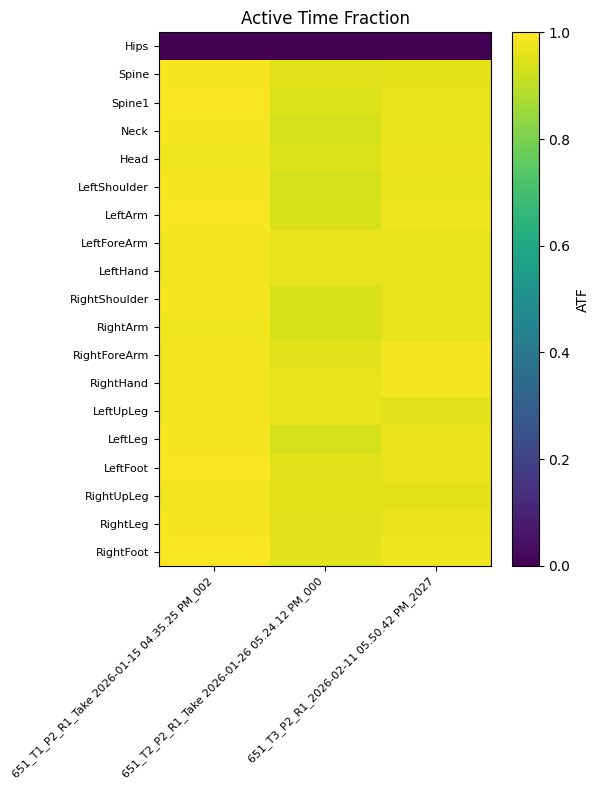

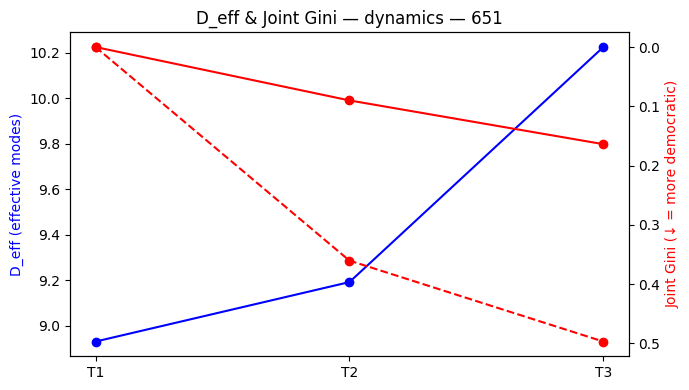

In [17]:
# ── Section 7 widgets ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt

w_export_path = widgets.Text(
    value=str(RESULTS_DIR),
    description="Output dir:",
    style={"description_width": "100px"},
    layout=widgets.Layout(width="560px"),
)
w_export_btn = widgets.Button(
    description="💾 Export Results",
    button_style="success",
    icon="save",
    layout=widgets.Layout(width="200px"),
)
w_export_out = widgets.Output()


def on_export_clicked(b):
    with w_export_out:
        clear_output(wait=True)

        results_df   = _STATE.get("results_df")
        delta_df     = _STATE.get("delta_df")
        bundle       = _STATE.get("bundle")
        pca_output   = _STATE.get("pca_output")
        bootstrap_df = _STATE.get("bootstrap_df")

        if results_df is None or bundle is None:
            display(HTML("<p style='color:red'>Run the pipeline first (Section 3).</p>"))
            return

        out_dir = Path(w_export_path.value)
        out_dir.mkdir(parents=True, exist_ok=True)

        subj = bundle.subject_id
        prefix = out_dir / f"Subject_{subj}_thesis_metrics"
        exported = []

        # 1. Tidy metric table → parquet
        p = str(prefix) + ".parquet"
        results_df.to_parquet(p, index=False)
        exported.append(p)

        # 2. Delta summary → JSON
        if delta_df is not None:
            p = str(prefix) + "_delta.json"
            delta_df.to_json(p, orient="records", indent=2)
            exported.append(p)

        # 3. Bootstrap CI → parquet (if available)
        if bootstrap_df is not None:
            p = str(prefix) + "_bootstrap_ci.parquet"
            bootstrap_df.to_parquet(p, index=False)
            exported.append(p)

        # 4. Figures
        branch_for_figs = w_branch.value if "w_branch" in dir() else "dynamics"
        fig_defs = []

        # ATF heatmap
        atf_by_run = _STATE.get("atf_by_run", {})
        if atf_by_run:
            fig_pl, fig_mpl = plot_atf_heatmap(
                atf_by_run, [subj],
                save_path=out_dir / f"Subject_{subj}_atf_heatmap",
            )
            fig_defs.append(("atf_heatmap", fig_pl, fig_mpl))

        # Gini trajectories
        fig_pl, fig_mpl = plot_gini_trajectories(
            bundle, branch=branch_for_figs,
            save_path=out_dir / f"Subject_{subj}_gini_traj",
        )
        fig_defs.append(("gini_trajectories", fig_pl, fig_mpl))

        # Variance structure
        if pca_output:
            pca_results  = pca_output["pca_results"]
            n90_res      = {br: {"n90_per_session": bundle.n90.get(br, []),
                                 "d_eff_per_session": bundle.d_eff.get(br, [])}
                            for br in BRANCHES}
            fig_pl, fig_mpl = plot_variance_structure(
                pca_results, n90_res, n90_res,
                branch=branch_for_figs,
                save_path=out_dir / f"Subject_{subj}_variance_structure",
            )
            fig_defs.append(("variance_structure", fig_pl, fig_mpl))

            # Entropy landscape
            fig_ent = plot_entropy_landscape(
                bundle, pca_output,
                branch=branch_for_figs,
                save_path=out_dir / f"Subject_{subj}_entropy_landscape",
            )
            fig_defs.append(("entropy_landscape", fig_ent, None))

        # Longitudinal summary
        if delta_df is not None:
            fig_pl, fig_mpl = plot_longitudinal_summary(
                delta_df,
                save_path=out_dir / f"Subject_{subj}_longitudinal_summary",
            )
            fig_defs.append(("longitudinal_summary", fig_pl, fig_mpl))

        # Save each figure
        for fig_name, fig_pl, fig_mpl in fig_defs:
            base = out_dir / f"Subject_{subj}_{fig_name}"
            if fig_pl is not None:
                try:
                    html_p = str(base) + ".html"
                    fig_pl.write_html(html_p)
                    exported.append(html_p)
                except Exception as ex:
                    display(HTML(f"<p style='color:orange'>⚠ {fig_name} HTML save: {ex}</p>"))
            if fig_mpl is not None:
                try:
                    png_p = str(base) + ".png"
                    pdf_p = str(base) + ".pdf"
                    fig_mpl.savefig(png_p, dpi=300, bbox_inches="tight")
                    fig_mpl.savefig(pdf_p, bbox_inches="tight")
                    plt.close(fig_mpl)
                    exported.extend([png_p, pdf_p])
                except Exception as ex:
                    display(HTML(f"<p style='color:orange'>⚠ {fig_name} PNG/PDF save: {ex}</p>"))

        # Summary
        display(HTML(
            f"<p style='color:green'>✔ Export complete — {len(exported)} files written to "
            f"<code>{out_dir}</code></p>"
        ))
        items = "".join(f"<li><code>{Path(p).name}</code></li>" for p in exported)
        display(HTML(f"<ul>{items}</ul>"))


w_export_btn.on_click(on_export_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>Section 7 — Export</h3>"),
    widgets.HTML(
        "<p>Exports: tidy parquet, delta JSON, bootstrap CI parquet, "
        "Plotly HTML, Matplotlib PNG (300 dpi) &amp; PDF.</p>"
    ),
    w_export_path,
    w_export_btn,
    w_export_out,
]))